In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import json
import numpy as np
import matplotlib.pyplot as plt
import glob
import os
from pathlib import Path
import sys
import pandas as pd

import cogwheel.cosmology
import cogwheel.data
import cogwheel.posterior
import cogwheel.sampling
import cogwheel.gw_plotting
import cogwheel.gw_utils
from cogwheel.plotting import latex_val_err
from cogwheel.likelihood.marginalization.coherent_score_lensing import bayes_factor_p_lensed, \
                                                                        get_bayes_factor_of_samples, \
                                                                        bootstrap_bayes_factors

import gwosc
import gwpy.table
from pesummary.io import read

import warnings
warnings.simplefilter("ignore", RuntimeWarning)

sys.path.insert(0, '/home/abbye.williams/GWPE/code')
from parameter_estimation import load_posterior_samples, load_lvk_samples, add_derived_quantities
from pe_injections import chirp_mass

In [2]:
# plotting helper
def plot_p_lensed(samples, eventname=None, fig=None, return_ax=False, bins=100, **kwargs):
    cp = cogwheel.gw_plotting.CornerPlot(
        samples, params=['p_lensed'], tail_probability=1e-4
    )
    hist, edges = np.histogram(samples['p_lensed'], bins=bins,
                               weights=samples['weights'])
    # we want the pdf at edges, not midpoints:
    pdf = np.array([hist[0], *(hist[1:] + hist[:-1]) / 2, hist[-1]])
    
    if fig is None:
        fig, ax = plt.subplots(figsize=(5,4))
    else:
        fig, ax = fig, plt.gca()
    ax.plot(edges, pdf, c='navy', alpha=0.9, **kwargs)
    ax.axvline(0.5, c='k', alpha=0.5, ls='--', lw=1.)
    # ax.set_xlabel('p_lensed')
    ax.set_xlim(0., 1.)
    ax.set_ylim(0., None)
    
    # vlines
    median, *span = cp._get_median_and_central_interval('p_lensed')
    for val in (median, *span):
        ax.plot([val] * 2, [0, np.interp(val, edges, pdf)], c='navy', alpha=0.8, lw=0.5)
    idx = (edges > span[0]) & (edges < span[1])
    ax.fill_between(edges[idx], np.zeros_like(pdf[idx]), pdf[idx], color='navy', alpha=0.1)
    # val_err_str = '${}={}$' + latex_val_err(median, np.subtract(median, span))
    # title_str = "p_lensed" if eventname is None else f"{eventname}: p_lensed"
    # ax.set_title(title_str + val_err_str)
    if return_ax:
        return ax

### real data

In [3]:
eventname = 'GW230630_234532'
event_path = os.path.join('../data/pe_runs_lensing/IntrinsicLVCPrior', eventname)
samples = load_posterior_samples(eventname, event_path)

loaded posterior samples for GW230630_234532 run 0


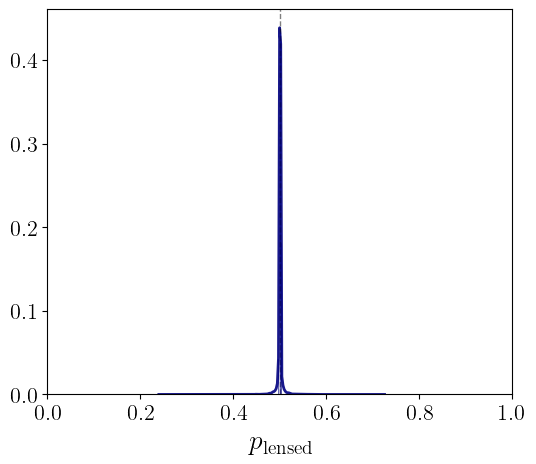

In [4]:
cp = cogwheel.gw_plotting.CornerPlot(
        samples, params=['p_lensed'], tail_probability=1e-4
    )
hist, edges = np.histogram(samples['p_lensed'], bins=200,
                            weights=samples['weights'])
# we want the pdf at edges, not midpoints:
pdf = np.array([hist[0], *(hist[1:] + hist[:-1]) / 2, hist[-1]])

fig, ax = plt.subplots(figsize=(6,5))
ax.plot(edges, pdf, c='navy', alpha=0.9, lw=2)
ax.axvline(0.5, c='k', alpha=0.5, ls='--', lw=1.)
ax.set_xlim(0., 1.)
ax.set_ylim(0., None)

# vlines
median, *span = cp._get_median_and_central_interval('p_lensed')
for val in (median, *span):
    ax.plot([val] * 2, [0, np.interp(val, edges, pdf)], c='navy', alpha=0.8, lw=0.5)
idx = (edges > span[0]) & (edges < span[1])
ax.fill_between(edges[idx], np.zeros_like(pdf[idx]), pdf[idx], color='navy', alpha=0.1)

ax.set_xlabel(r'$p_\mathrm{lensed}$', fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=16)

# val_err_str = r'$p_\mathrm{lensed}={}$' + latex_val_err(median, np.subtract(median, span))
# ax.text(0.55, 0.3, val_err_str, fontsize=14)

In [5]:
# compute Bayes factor and uncertainty
n_resamples = 1000
bayes_factors_ = bootstrap_bayes_factors(samples, n_resamples)
print(np.median(bayes_factors_), np.std(bayes_factors_))

1.000284536000597 0.00020082014445476208


2026-04-20  11:05:30 PESummary WARNING : Unable to install 'pycbc'. You will not be able to use some of the inbuilt functions.
2026-04-20  11:05:30 PESummary WARNING : Unable to install 'pycbc'. You will not be able to use some of the inbuilt functions.


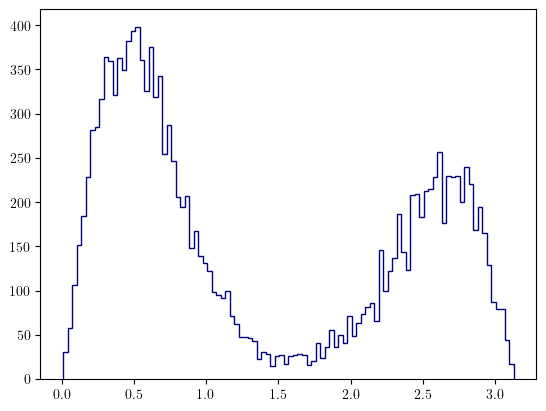

In [6]:
# other parameter estimates
samples_lvk = load_lvk_samples(eventname)

fig, ax = plt.subplots()
_, _, _ = ax.hist(samples_lvk['iota'], bins=100, histtype='step', color='navy')

In [7]:
# load injection results

# load our posterior samples and the released samples from the LVK PE
resdir = '../data/pe_runs_lensing/injections/IntrinsicLVCPrior'
# get the results here
event_dir_list = glob.glob(f'{resdir}/GW*')
eventname_list = [
    event_dir.split('/')[-1] for event_dir in event_dir_list
]
print(f"found {len(eventname_list)} events")

found 10 events


In [8]:
# load the event data
eventname = 'GW22'
i = eventname_list.index(eventname)
event_data = cogwheel.data.EventData.from_npz(filename=os.path.join(event_dir_list[i], 'run_0', f'{eventname}.npz'))

In [9]:
# what are the injected parameters?
event_data.injection

{'par_dic': {'f_ref': 100.0,
  'm1': 60,
  'm2': 20,
  's1z': 0.0,
  's2z': 0.0,
  'psi': 0.5,
  'iota': 1.4707963267948965,
  's1x_n': 0.0,
  's1y_n': 0.0,
  's2x_n': 0.0,
  's2y_n': 0.0,
  'ra': 3.0,
  'dec': -0.5,
  't_geocenter': 0.0,
  'phi_ref': 0.43867,
  'd_luminosity': 1000.0,
  'l1': 0.0,
  'l2': 0.0},
 'approximant': 'IMRPhenomXPHM',
 'd_h': array([113.90850488, 162.05204256,   0.77801877]),
 'h_h': array([110.04052608, 167.2238733 ,   1.49075237])}

In [10]:
# load the posterior samples
samples = load_posterior_samples(eventname, event_dir_list[i])
# add derived quantities
add_derived_quantities(samples)

# plot parameters for our cogwheel results
plot_params = ['m1', 'm2', 'iota', 'p_lensed']

# plot the injected params
injected_par_dict = event_data.get_init_dict()['injection']['par_dic']
# also add the chirp mass
injected_par_dict['mchirp'] = chirp_mass(injected_par_dict['m1'], injected_par_dict['m2'])
injected_par_dict['chieff'] = cogwheel.gw_utils.chieff(injected_par_dict['m1'], injected_par_dict['m2'],
                                                        injected_par_dict['s1z'], injected_par_dict['s2z'])
# match the injected pars to plot
injected_pars_keys = ['m1', 'm2', 'iota']
# get the subset of the data release posterior parameters
injected_pars_to_plot = {}
for key, value in injected_par_dict.items():
    if key in injected_pars_keys:
        injected_pars_to_plot[key] = value

loaded posterior samples for GW22 run 0


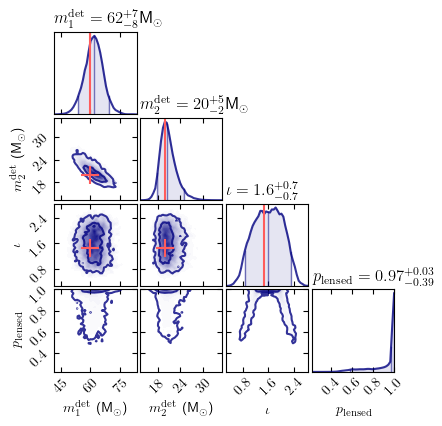

In [11]:
c = 'navy'
corner_plot = cogwheel.gw_plotting.CornerPlot(
        samples, params=plot_params, tail_probability=1e-4, color_2d=c,
        kwargs_1d=dict(color=c, alpha=0.8), contour_kwargs=dict(alpha=0.8)
)
corner_plot.plot(max_figsize=5)
corner_plot.scatter_points(injected_pars_to_plot, colors=['#FF5C5C'], s=150,
                               zorder=2, marker='+', adjust_lims=True)

In [14]:
# compute Bayes factor and uncertainty
n_resamples = 1000
bayes_factors = bootstrap_bayes_factors(samples, n_resamples)
# log these
lnbayes_factors = np.log(bayes_factors)
# get the median and standard deviation
lnbayes, lnbayes_std = np.median(lnbayes_factors), np.std(lnbayes_factors)
print(lnbayes, lnbayes_std)

2.1052409987280067 0.01580940360020267


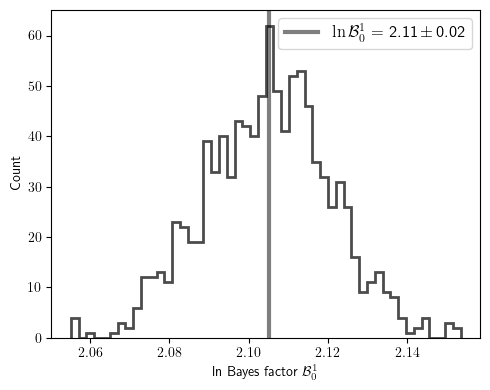

In [15]:
fig, ax = plt.subplots(figsize=(5,4), tight_layout=True)
_, _, _ = ax.hist(lnbayes_factors, histtype='step', color='k', alpha=0.7, bins=50, lw=2)
ax.axvline(lnbayes, c='k', lw=3, alpha=0.5, ls='-', label=r'$\ln\mathcal{B}_0^1 = $ 'f'{lnbayes:.2f}'r'$\,\pm\,$'f'{lnbayes_std:.2f}')
ax.set_xlabel(r'ln Bayes factor $\mathcal{B}_0^1$')
ax.set_ylabel('Count')
ax.legend(fontsize=12)

In [ ]:
# plot the plensed distribution
cp = cogwheel.gw_plotting.CornerPlot(
        samples, params=['p_lensed'], tail_probability=1e-4
    )
hist, edges = np.histogram(samples['p_lensed'], bins=200,
                            weights=samples['weights'])
# we want the pdf at edges, not midpoints:
pdf = np.array([hist[0], *(hist[1:] + hist[:-1]) / 2, hist[-1]])

fig, ax = plt.subplots(figsize=(6,5))
ax.plot(edges, pdf, c='navy', alpha=0.9, lw=3)
ax.axvline(0.5, c='k', alpha=0.5, ls='--', lw=1.)
ax.set_xlim(0., 1.)
ax.set_ylim(0., None)

# vlines
median, *span = cp._get_median_and_central_interval('p_lensed')
for val in (median, *span):
    ax.plot([val] * 2, [0, np.interp(val, edges, pdf)], c='navy', alpha=0.8, lw=1)
idx = (edges > span[0]) & (edges < span[1])
ax.fill_between(edges[idx], np.zeros_like(pdf[idx]), pdf[idx], color='navy', alpha=0.1)

ax.set_xlabel(r'$p_\mathrm{lensed}$', fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=16)

val_err_str = r'$p_\mathrm{lensed}={}$' + latex_val_err(median, np.subtract(median, span))
ax.text(0.55, 0.2, val_err_str, fontsize=18